In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

In [15]:
datasets = ['assistments',
    'diabetes_readmission',
    'brfss_blood_pressure',
    'mimic_extract_los_3',
    'physionet',
    'acspubcov',
    'meps',
    'acsincome',
    'acsfoodstamps',
    'brfss_diabetes',
    'anes',
    'college_scorecard',
    'mimic_extract_mort_hosp',
    'nhanes_lead',
    'sipp',
    'acsunemployment',
    ]

In [16]:

# Directory where CSV files are stored
data_dir = "./"  # Adjust path if needed

# Read and combine all datasets
df_list_with = []
df_list_without = []
df_list_with_avg = []
df_list_without_avg = []

for dataset_name in datasets:
    temp_df = pd.read_csv(os.path.join(data_dir, f"{dataset_name}_eval.csv"))
    temp_df["dataset_name"] = dataset_name  # Add dataset column
    temp_df_with = pd.DataFrame()
    temp_df_without = pd.DataFrame()
    temp_df_with_avg = pd.DataFrame()
    temp_df_without_avg = pd.DataFrame()

    # for every value of 'features', plot histogram of 'models'
    for features in temp_df["features"].unique():
        # Filter DataFrame
        df_filtered = temp_df[temp_df["features"] == features]
        df_filtered_with = pd.DataFrame()
        df_filtered_without = pd.DataFrame()

        # in case there are several rows with the same model, average them
        for models in df_filtered["model"].unique():
            df_filtered_model = df_filtered[df_filtered["model"] == models]
            row_with = df_filtered_model.mean(numeric_only=True)
            for col in df_filtered_model.columns:
                if col not in row_with:
                    row_with[col] = df_filtered_model[col].iloc[0]

            df_filtered_with = pd.concat([df_filtered_with, row_with.to_frame().T], ignore_index=True)
            if "tableshift" not in models:
                df_filtered_without = pd.concat([df_filtered_without, row_with.to_frame().T], ignore_index=True)

        # average all models for the same features
        row_with = df_filtered_with.mean(numeric_only=True)
        row_without = df_filtered_without.mean(numeric_only=True)
        row_with_avg = df_filtered.mean(numeric_only=True)
        row_without_avg = df_filtered[df_filtered["model"] != "tableshift"].mean(numeric_only=True)
        for col in df_filtered_with.columns: # add discrete columns
            if col not in row_with:
                row_with[col] = df_filtered_with[col].iloc[0]
                row_without[col] = df_filtered_without[col].iloc[0]
                row_with_avg[col] = df_filtered[col].iloc[0]
                row_without_avg[col] = df_filtered[col].iloc[0]
        
        temp_df_with = pd.concat([temp_df_with, row_with.to_frame().T], ignore_index=True)
        temp_df_without = pd.concat([temp_df_without, row_without.to_frame().T], ignore_index=True)
        temp_df_with_avg = pd.concat([temp_df_with_avg, row_with_avg.to_frame().T], ignore_index=True)
        temp_df_without_avg = pd.concat([temp_df_without_avg, row_without_avg.to_frame().T], ignore_index=True)


    df_list_with.append(temp_df_with)
    df_list_without.append(temp_df_without)
    df_list_with_avg.append(temp_df_with_avg)
    df_list_without_avg.append(temp_df_without_avg)

# Merge all into a single DataFrame
df_with = pd.concat(df_list_with, ignore_index=True)
df_without = pd.concat(df_list_without, ignore_index=True)
df_with_avg = pd.concat(df_list_with_avg, ignore_index=True)
df_without_avg = pd.concat(df_list_without_avg, ignore_index=True)

# drop for dataset_name=assistments, features=causal
# df = df[~((df["dataset_name"] == "assistments") & (df["features"] == "causal"))]
# df = df[~((df["dataset_name"] == "acspubcov") & (df["features"] == "causal"))]


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_ood_and_shift_gap(df,title):
    # Define marker styles based on the 'features' column
    marker_map = {
        "arguablycausal": "D",
        "causal": "o",
        "constant": "X",
        "all": "s",
    }

    # Set colors
    color_map = {
        "arguablycausal": "gray",
        "causal": "blue",
        "constant": "black",
        "all": "red",
    }

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Sort datasets by OOD accuracy for consistent x-axis order
    sorted_datasets = df[df["features"] == "all"].sort_values("ood_test")["dataset_name"]
    df["dataset_name"] = pd.Categorical(df["dataset_name"], categories=sorted_datasets, ordered=True)

    # Left Plot: Out-of-domain accuracy
    sns.scatterplot(
        data=df, x="dataset_name", y="ood_test", hue="features", style="features",
        markers=marker_map, palette=color_map, ax=axes[0], s=100
    )

    # Add error bars
    for dataset in df["dataset_name"].unique():
        subset = df[df["dataset_name"] == dataset]
        for _, row in subset.iterrows():
            axes[0].errorbar(dataset, row["ood_test"], 
                             yerr=[[row["ood_test"] - row["ood_test_lb"]], [row["ood_test_ub"] - row["ood_test"]]],
                             fmt='none', ecolor=color_map[row["features"]], capsize=3)

    axes[0].set_ylabel("Out-of-domain accuracy")
    axes[0].set_xlabel("Tasks")
    axes[0].set_xticklabels(sorted_datasets, rotation=45, ha="right")

    # Right Plot: Shift gap
    df["shift_gap"] = df["ood_test"] - df["id_test"]

    sns.scatterplot(
        data=df, x="dataset_name", y="shift_gap", hue="features", style="features",
        markers=marker_map, palette=color_map, ax=axes[1], s=100,
    )

    # Add error bars
    for dataset in df["dataset_name"].unique():
        subset = df[df["dataset_name"] == dataset]
        for _, row in subset.iterrows():
            axes[1].errorbar(dataset, row["shift_gap"], 
                             yerr=[[row["id_test"] - row["id_test_lb"]], [row["id_test_ub"] - row["id_test"]]],
                             fmt='none', ecolor=color_map[row["features"]], capsize=3)

    axes[1].axhline(0, linestyle="--", color="black")  # Dashed line for zero shift gap
    axes[1].set_ylabel("Shift gap (higher is better)")
    axes[1].set_xlabel("Tasks")
    axes[1].set_xticklabels(sorted_datasets, rotation=45, ha="right")

    # Adjust legend and layout
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Features", loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.1))
    axes[0].get_legend().remove()
    axes[1].get_legend().remove()

    fig.suptitle(title)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_699934/3403953693.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(sorted_datasets, rotation=45, ha="right")
/tmp/ipykernel_699934/3403953693.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(sorted_datasets, rotation=45, ha="right")


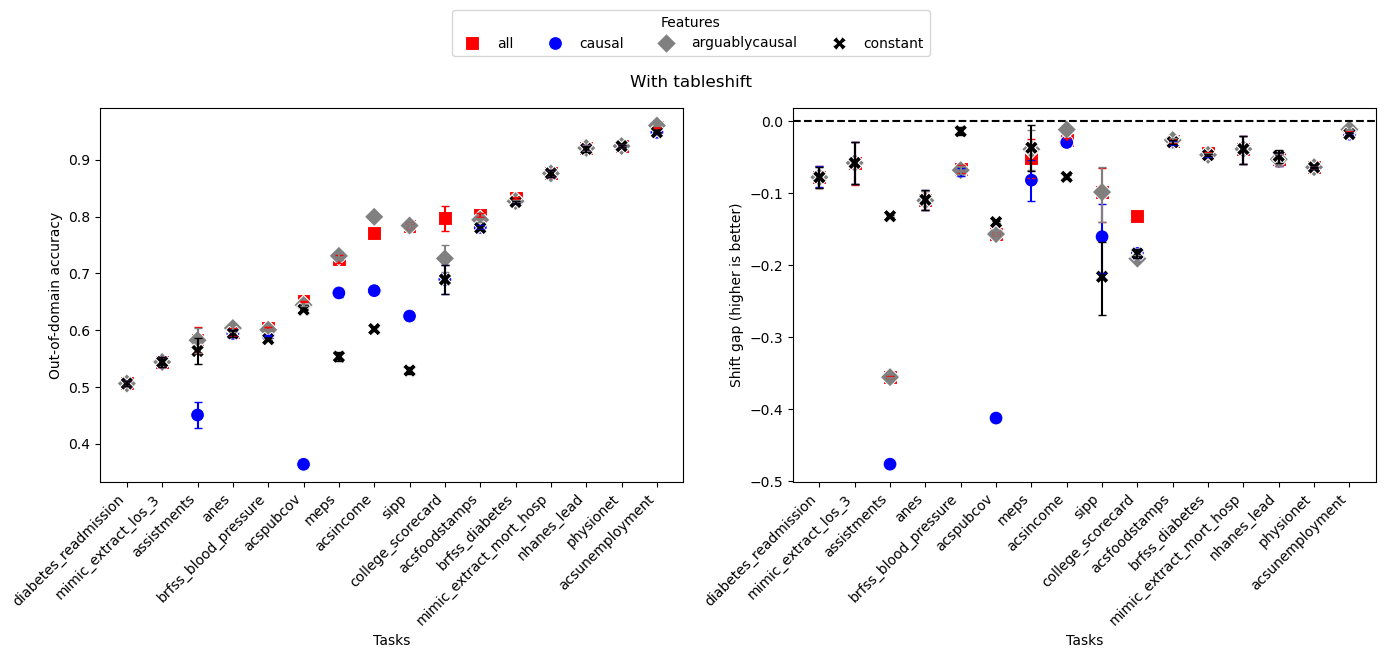

/tmp/ipykernel_699934/3403953693.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(sorted_datasets, rotation=45, ha="right")
/tmp/ipykernel_699934/3403953693.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(sorted_datasets, rotation=45, ha="right")


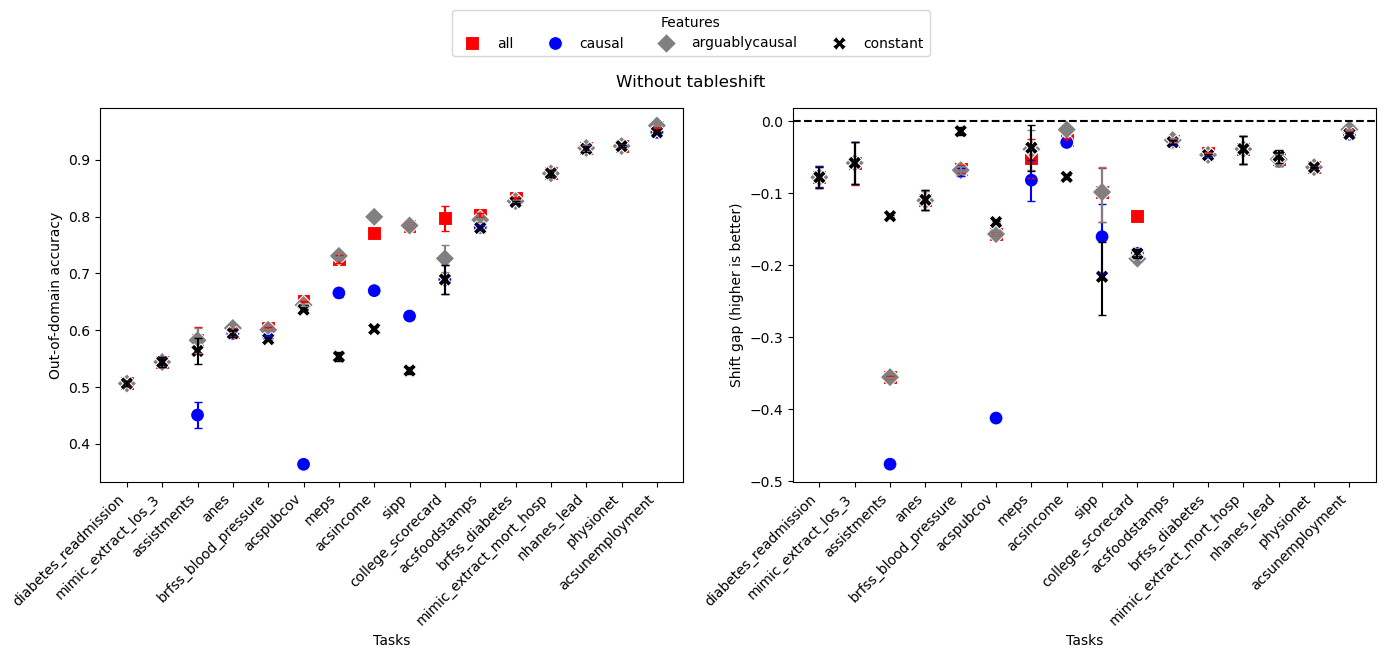

/tmp/ipykernel_699934/3403953693.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(sorted_datasets, rotation=45, ha="right")
/tmp/ipykernel_699934/3403953693.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(sorted_datasets, rotation=45, ha="right")


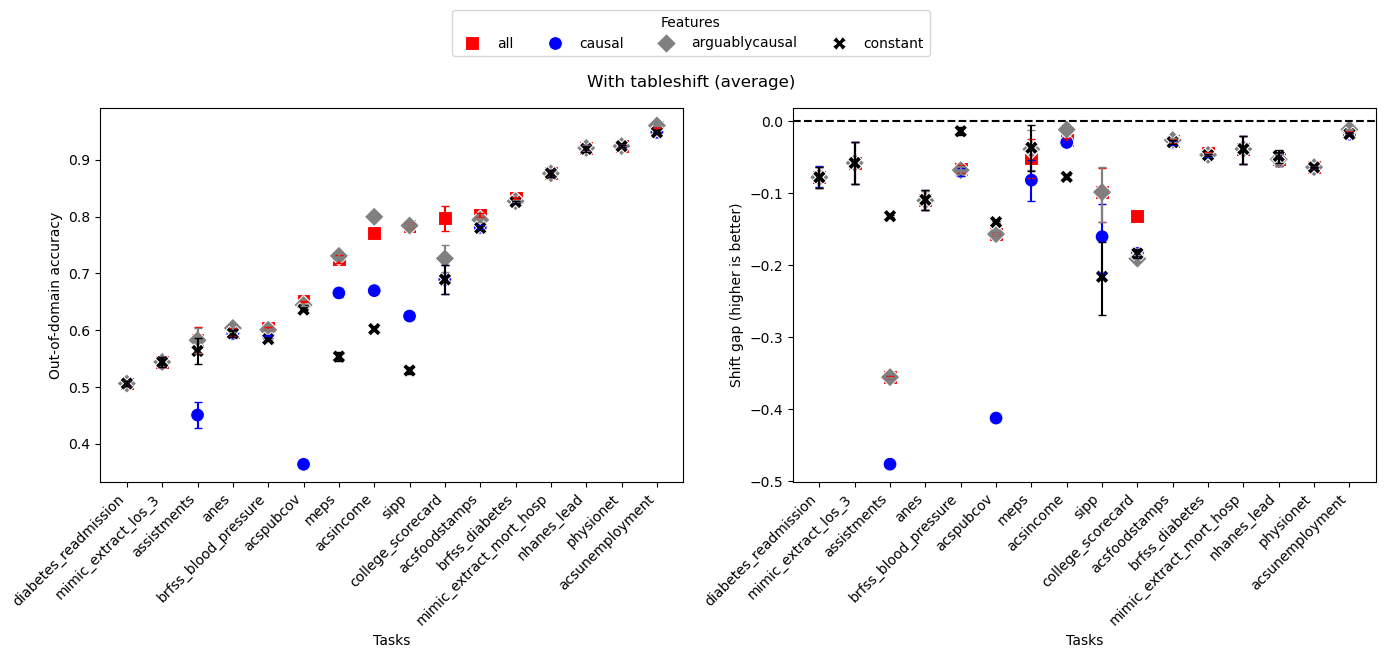

/tmp/ipykernel_699934/3403953693.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(sorted_datasets, rotation=45, ha="right")
/tmp/ipykernel_699934/3403953693.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(sorted_datasets, rotation=45, ha="right")


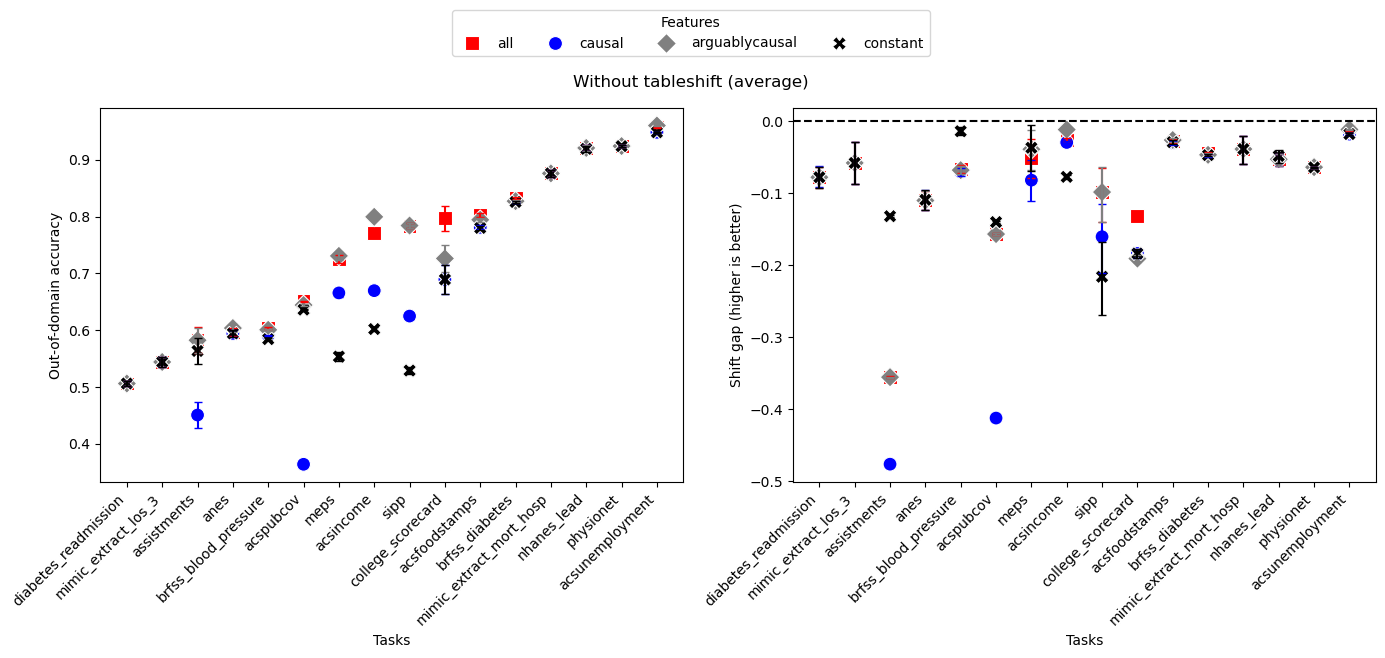

In [18]:
plot_ood_and_shift_gap(df_with, "With tableshift")
plot_ood_and_shift_gap(df_without, "Without tableshift")
plot_ood_and_shift_gap(df_with_avg, "With tableshift (average)")
plot_ood_and_shift_gap(df_without_avg, "Without tableshift (average)")